In [2]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from Raster_hist_plots import *
from read_data import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
# Name_BCM = "Learned_BCM"
# time_now_BCM = "09:15"
# Name_No_BCM = "No_BCM"
# time_now_No_BCM = "09:47"
# date = "06-07"
Name_BCM = "Learned_BCM"
time_now_BCM = "21:54"
Name_No_BCM = "No_BCM"
time_now_No_BCM = "15:10"
date = "06-10"
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled = load_data(Name_No_BCM, time_now_No_BCM, date)
Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled = load_data(Name_BCM, time_now_BCM, date)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_BCM,"",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_BCM,"Coupled",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
time_x_BCM = Noise_BCM.t

Noise_No_BCM, Noise_Extended_No_BCM, PC_No_BCM, DCN_No_BCM, IO_No_BCM, mon_N_PC_No_BCM = Output_func(Name_No_BCM,"",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_No_BCM, Noise_Extended_Coupled_No_BCM, PC_Coupled_No_BCM, DCN_Coupled_No_BCM, IO_Coupled_No_BCM, mon_N_PC_Coupled_No_BCM = Output_func(Name_No_BCM,"Coupled",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
time_x_No_BCM = Noise_No_BCM.t

step1 = 550
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

%%time
f_No_BCM = [[]]*Params.N_Cells_PC
f_During_BCM = [[]]*Params.N_Cells_PC
f_BCM = [[]]*Params.N_Cells_PC
f_Coupled_No_BCM = [[]]*Params.N_Cells_PC
f_Coupled_During_BCM = [[]]*Params.N_Cells_PC
f_Coupled_BCM = [[]]*Params.N_Cells_PC
cxy_No_BCM = [[]]*Params.N_Cells_PC
cxy_During_BCM = [[]]*Params.N_Cells_PC
cxy_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    f_No_BCM[ii] = [[]]*Params.N_Noise
    f_During_BCM[ii] = [[]]*Params.N_Noise
    f_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_BCM[ii] = [[]]*Params.N_Noise
    cxy_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):     
        cxy_No_BCM[ii][jj], f_No_BCM[ii][jj] = cohere(PC_No_BCM.I_Noise[ii]/nA, Noise_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_During_BCM[ii][jj], f_During_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][:len(PC_BCM.I_Noise[ii])//2]/nA, Noise_Extended_BCM.I[jj][:len(Noise_Extended_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_BCM[ii][jj], f_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][len(PC_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_BCM.I[jj][len(Noise_Extended_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_No_BCM[ii][jj], f_Coupled_No_BCM[ii][jj] = cohere(PC_Coupled_No_BCM.I_Noise[ii]/nA, Noise_Coupled_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_During_BCM[ii][jj], f_Coupled_During_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][:len(PC_Coupled_BCM.I_Noise[ii])//2]/nA, Noise_Extended_Coupled_BCM.I[jj][:len(Noise_Extended_Coupled_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_BCM[ii][jj], f_Coupled_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][len(PC_Coupled_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_Coupled_BCM.I[jj][len(Noise_Extended_Coupled_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
    xscale('log')
    
mean_point_cxy_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    mean_point_cxy_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):
        idx_aa = []
        for kk in range(0,len(f_No_BCM[ii][jj])):
            if 10**2 <= f_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_No_BCM[ii][jj] = mean(cxy_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_During_BCM[ii][jj])):
            if 10**2 <= f_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_During_BCM[ii][jj] = mean(cxy_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_BCM[ii][jj])):
            if 10**2 <= f_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_BCM[ii][jj] = mean(cxy_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_No_BCM[ii][jj])):
            if 10**2 <= f_Coupled_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_No_BCM[ii][jj] = mean(cxy_Coupled_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_During_BCM[ii][jj])):
            if 10**2 <= f_Coupled_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_During_BCM[ii][jj] = mean(cxy_Coupled_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_BCM[ii][jj])):
            if 10**2 <= f_Coupled_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_BCM[ii][jj] = mean(cxy_Coupled_BCM[ii][jj][idx_aa])
        

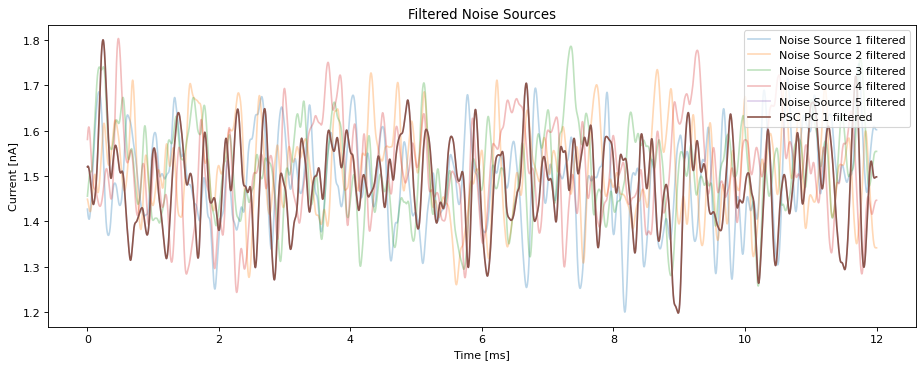

In [26]:
fs = 1/(Params.dt/second)  # Sampling frequency
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
for ii in range(0,Params.N_Noise):
    t = np.arange(len(Noise_No_BCM.I[ii]))/fs
    signala = Noise_No_BCM.I[ii] # with frequency of 100
    fc = 5  # Cut-off frequency of the filter
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(2, w, 'low')
    output = signal.filtfilt(b, a, signala/nA)
    plt.plot(t, output, label="Noise Source "+str(ii+1)+' filtered', alpha=0.3)
signala = PC_No_BCM.I_Noise[0] # with frequency of 100    
plt.plot(t, output, label='PSC PC 1 filtered', alpha=3)
ylabel('Current [nA]')
xlabel('Time [ms]')
title('Filtered Noise Sources')
legend(loc='upper right')
show()

In [165]:
len(time_x_No_BCM)*Params.dt/second

12.0

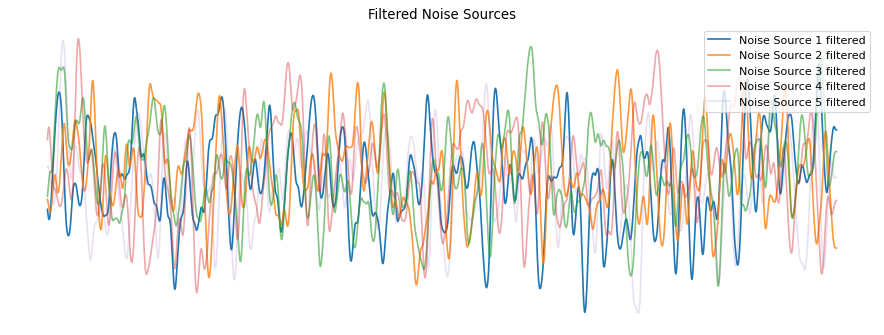

In [37]:
fs = 1/(Params.dt/second)  # Sampling frequency
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
for ii in range(0,Params.N_Noise):
    t = np.arange(len(Noise_No_BCM.I[ii]))/fs
    signala = Noise_No_BCM.I[ii] # with frequency of 100
    fc = 5  # Cut-off frequency of the filter
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(2, w, 'low')
    output = signal.filtfilt(b, a, signala/nA)
    plt.plot(t, output, label="Noise Source "+str(ii+1)+' filtered', alpha=1-(ii*2/10))
ylabel('Current [nA]')
xlabel('Time [ms]')
title('Filtered Noise Sources')
legend(loc='upper right')
plt.axis('off')
show()

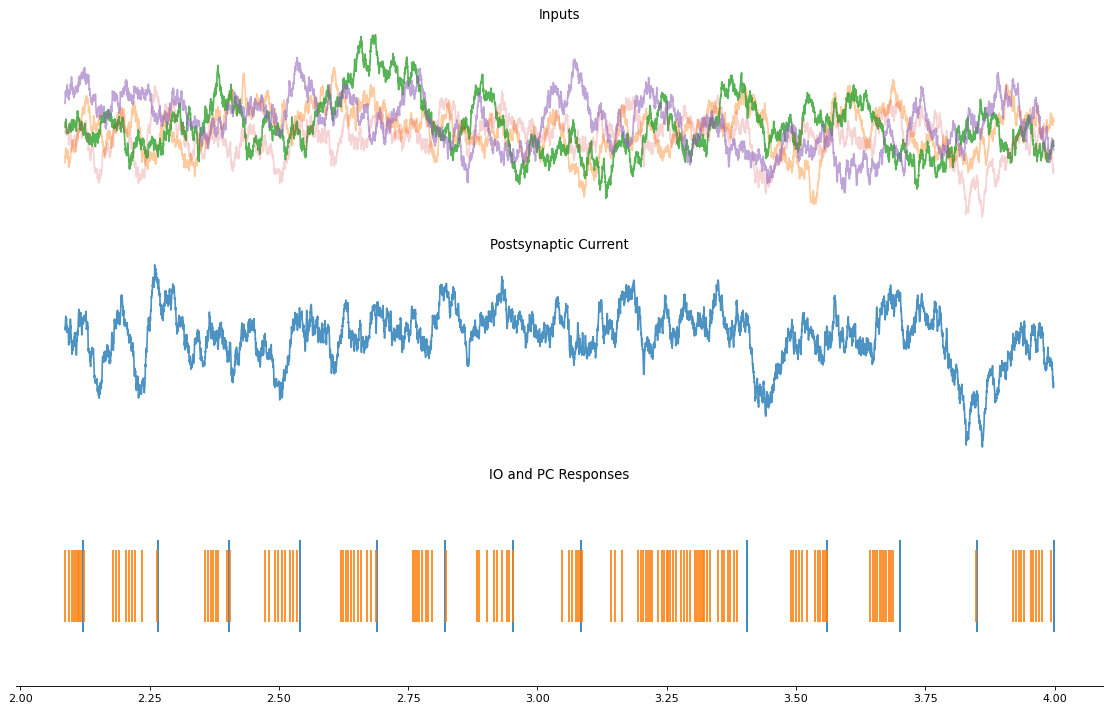

In [247]:
start = int(2/Params.dt_rec)
end = int(4/Params.dt_rec)
fs = 1/(Params.dt/second)  # Sampling frequency
fig, ax = plt.subplots(3, 1,figsize=(14, 3*3), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Noise):
    ax[0].plot(time_x_BCM[start:end], Noise_No_BCM.I[ii][start:end], alpha=(ii*4/10))
ax[0].set_title("Inputs")
ax[0].set_axis_off()

ax[1].plot(time_x_BCM[start:end],PC_No_BCM.I_Noise[0][start:end]/nA,alpha=0.8)
ax[1].set_title("Postsynaptic Current")
ax[1].set_axis_off()
# ax[1].set_ylim([1.2,1.8])
# ax[1].spines['right'].set_visible(False)
# ax[1].spines['top'].set_visible(False)
# ax[1].spines['bottom'].set_visible(False)

IO_spikes_aa = []
for ii in range(0,len(IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]])):
    if int(start*Params.dt_rec/second) <= IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]][ii] <= int(end*Params.dt_rec/second):
        IO_spikes_aa.append(IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]][ii])
PC_spikes_aa = []
for ii in range(0,len(PC_No_BCM.Spikemon_Cells[0])):
    if int(start*Params.dt_rec/second) <= PC_No_BCM.Spikemon_Cells[0][ii] <= int(end*Params.dt_rec/second):
        PC_spikes_aa.append(PC_No_BCM.Spikemon_Cells[0][ii])

data1 = [IO_spikes_aa,PC_spikes_aa]
  
colors1 = ['C{}'.format(i) for i in range(2)]
lineoffsets1 = np.array([1, 1])
  
linelengths1 = [1, 0.8]
   
# fig, axs = plt.subplots()
ax[2].eventplot(data1, colors=colors1, 
              lineoffsets=lineoffsets1,
              linelengths=linelengths1)
# ax[2].eventplot(PC_No_BCM.Spikemon_Cells[0][start:end], orientation = 'horizontal', linelengths = 2,color=[(0.5,0.5,0.8)])
# ax[2].eventplot(IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]][start:end], orientation = 'horizontal', lineoffsets=-1,linelengths = 1.2)
# ax[2].plot(time_x_BCM[start:end]/1000,IO_No_BCM.Vs[Synapses.IO_PC_Synapse_Sources[0]][start:end]/mV, alpha=0.8)
# ax[2].plot(time_x_BCM[start:end]/1000,PC_No_BCM.v[0][start:end]/mV)
ax[2].set_title("IO and PC Responses")
ax[2].spines['right'].set_visible(False)
ax[2].spines['top'].set_visible(False)
ax[2].spines['left'].set_visible(False)
ax[2].set_yticks([])
# sns.despine(offset=10, trim=True)

fig.tight_layout()
plt.show()

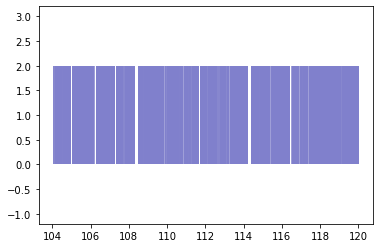

In [202]:

eventplot(PC_No_BCM.Spikemon_Cells[0][start:end], orientation = 'horizontal', linelengths = 2,color=[(0.5,0.5,0.8)])
eventplot(IO_No_BCM.Spikemon_Cells[0][start:end], orientation = 'horizontal', lineoffsets=-1,linelengths = 1.2)
# ax

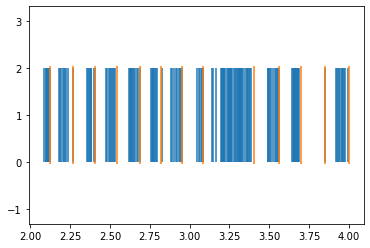

In [242]:
start = int(2/Params.dt_rec)
end = int(4/Params.dt_rec)
IO_spikes_aa = []
for ii in range(0,len(IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]])):
    if int(start*Params.dt_rec/second) <= IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]][ii] <= int(end*Params.dt_rec/second):
        IO_spikes_aa.append(IO_No_BCM.Spikemon_Cells[Synapses.IO_PC_Synapse_Sources[0]][ii])
PC_spikes_aa = []
for ii in range(0,len(PC_No_BCM.Spikemon_Cells[0])):
    if int(start*Params.dt_rec/second) <= PC_No_BCM.Spikemon_Cells[0][ii] <= int(end*Params.dt_rec/second):
        PC_spikes_aa.append(PC_No_BCM.Spikemon_Cells[0][ii])

data1 = [PC_spikes_aa,IO_spikes_aa]
  
colors1 = ['C{}'.format(i) for i in range(2)]
lineoffsets1 = np.array([1, 1])
  
linelengths1 = [2, 2.1]
   
fig, axs = plt.subplots()
axs.eventplot(data1, colors=colors1, 
              lineoffsets=lineoffsets1,
              linelengths=linelengths1)

In [237]:
data1

[array([104.0798  , 104.086325, 104.17795 , ..., 119.979025, 119.982725,
        119.987825]),
 [2.121425,
  2.2656,
  2.4032500000000003,
  2.5407,
  2.690275,
  2.8218750000000004,
  2.952475,
  3.0850500000000003,
  3.40475,
  3.559425,
  3.701975,
  3.84985,
  3.9981750000000003]]

In [166]:
# fs = 1/(Params.dt/second)  # Sampling frequency
# plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
# for ii in range(0,Params.N_Noise):
#     t = np.arange(len(Noise_No_BCM.I[ii]))/fs
#     signala = Noise_No_BCM.I[ii] # with frequency of 100
#     fc = 5  # Cut-off frequency of the filter
#     w = fc / (fs / 2) # Normalize the frequency
#     b, a = signal.butter(2, w, 'low')
#     output = signal.filtfilt(b, a, signala/nA)
#     plt.plot(t, output, label="Noise Source "+str(ii+1)+' filtered', alpha=(ii*4/10))
# # ylabel('Current [nA]')
# # xlabel('Time [ms]')
# # title('Filtered Noise Sources')
# # legend(loc='upper right')
# plt.axis('off')
# # sns.despine(offset=10, trim=True);
# show()

# plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
# t = np.arange(len(Noise_No_BCM.I[ii]))/fs
# signala = PC_No_BCM.I_Noise[0] # with frequency of 100
# fc = 5  # Cut-off frequency of the filter
# w = fc / (fs / 2) # Normalize the frequency
# b, a = signal.butter(2, w, 'low')
# output = signal.filtfilt(b, a, signala/nA)
# plt.plot(t, output, label="Noise Source "+str(ii+1)+' filtered', alpha=1-0.2)
# # ylabel('Current [nA]')
# # xlabel('Time [ms]')
# # title('Filtered Noise Sources')
# # legend(loc='upper right')
# ylim([1.2,1.8])
# plt.axis('off')
# # sns.despine(offset=10, trim=True);
# show()

# plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
# t = np.arange(len(Noise_No_BCM.I[ii]))/fs
# signala = PC_No_BCM.v[0] # with frequency of 100
# fc = 300  # Cut-off frequency of the filter
# w = fc / (fs / 2) # Normalize the frequency
# b, a = signal.butter(2, w, 'low')
# output = signal.filtfilt(b, a, signala/mV)
# plot(t,IO_No_BCM.Vs[Synapses.IO_PC_Synapse_Sources[0]]/mV, alpha=0.5)
# # plot(t,DCN_No_BCM.v[0]/mV, alpha=0.5)
# plt.plot(t, output, alpha=1-0.2)
# sns.despine(offset=10, trim=True);
# show()

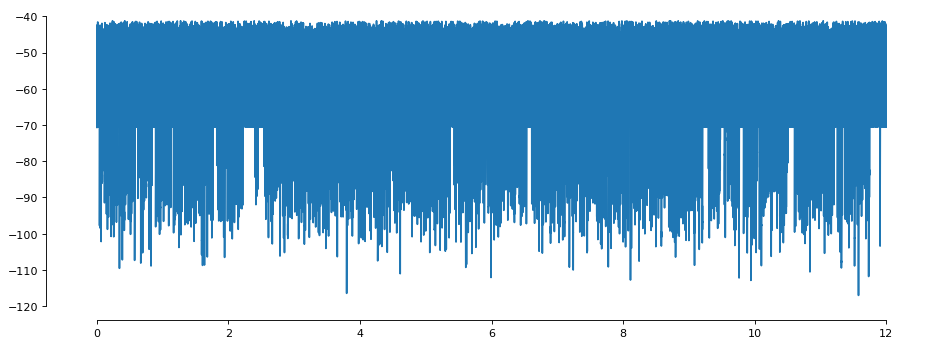

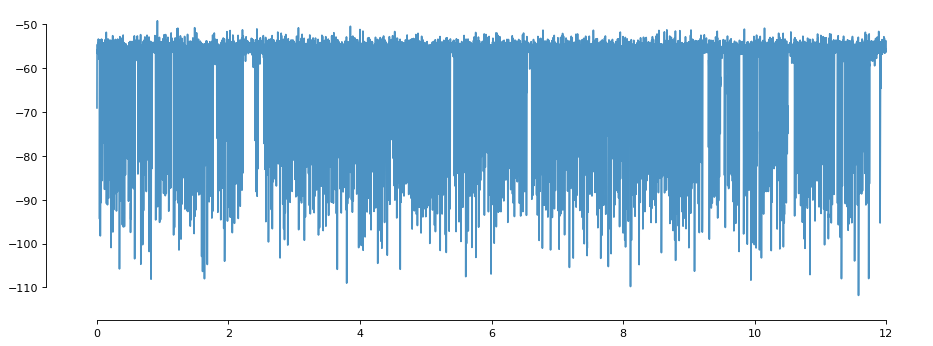

In [72]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
plot(t,PC_No_BCM.v[0]/mV)
sns.despine(offset=10, trim=True);

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
t = np.arange(len(Noise_No_BCM.I[ii]))/fs
signala = PC_No_BCM.v[0] # with frequency of 100
fc = 300  # Cut-off frequency of the filter
w = fc / (fs / 2) # Normalize the frequency
b, a = signal.butter(2, w, 'low')
output = signal.filtfilt(b, a, signala/mV)
plt.plot(t, output, alpha=1-0.2)
sns.despine(offset=10, trim=True);
show()

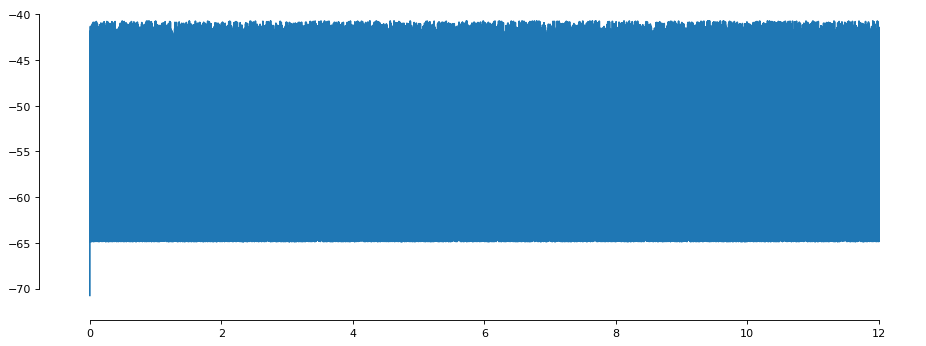

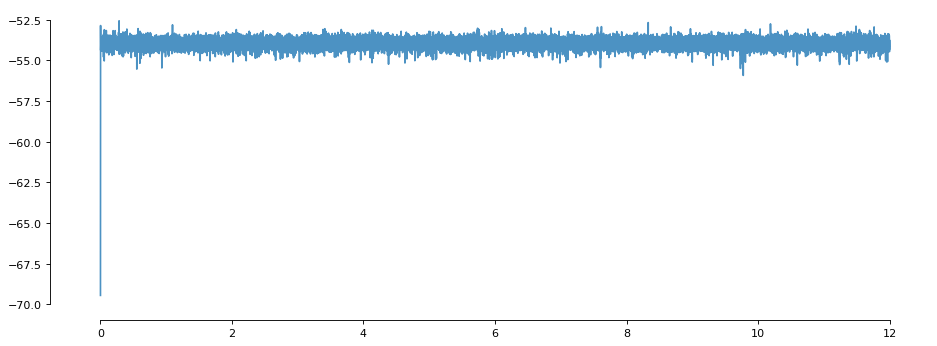

In [73]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
plot(t,DCN_No_BCM.v[0]/mV)
sns.despine(offset=10, trim=True);

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
t = np.arange(len(Noise_No_BCM.I[ii]))/fs
signala = DCN_No_BCM.v[0] # with frequency of 100
fc = 300  # Cut-off frequency of the filter
w = fc / (fs / 2) # Normalize the frequency
b, a = signal.butter(2, w, 'low')
output = signal.filtfilt(b, a, signala/mV)
plt.plot(t, output, alpha=1-0.2)
sns.despine(offset=10, trim=True);
show()

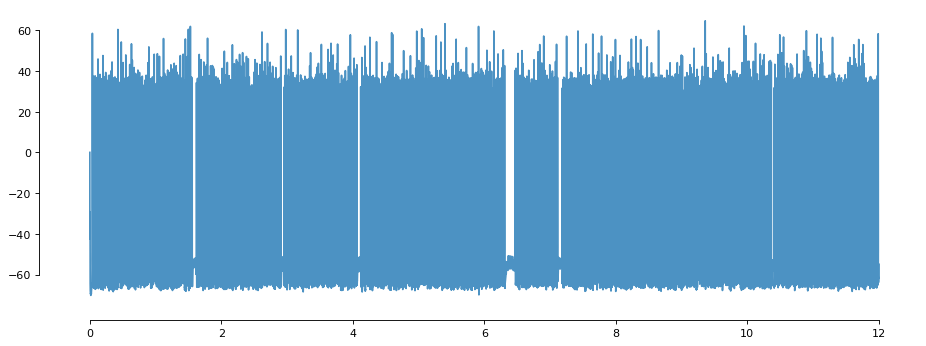

In [78]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
plot(t,IO_No_BCM.Vs[0]/mV, alpha=1-0.2)
sns.despine(offset=10, trim=True);
show()

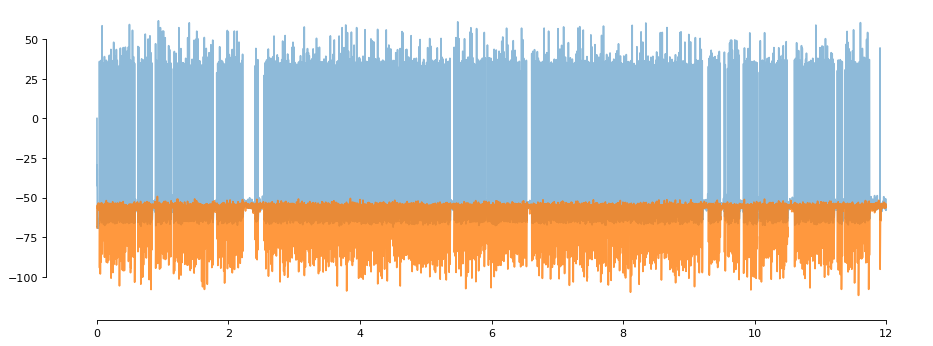

In [89]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
t = np.arange(len(Noise_No_BCM.I[ii]))/fs
signala = PC_No_BCM.v[0] # with frequency of 100
fc = 300  # Cut-off frequency of the filter
w = fc / (fs / 2) # Normalize the frequency
b, a = signal.butter(2, w, 'low')
output = signal.filtfilt(b, a, signala/mV)
plot(t,IO_No_BCM.Vs[Synapses.IO_PC_Synapse_Sources[0]]/mV, alpha=0.5)
# plot(t,DCN_No_BCM.v[0]/mV, alpha=0.5)
plt.plot(t, output, alpha=1-0.2)
sns.despine(offset=10, trim=True);
show()

In [86]:
Synapses.PC_DCN_Synapse_Targets

array([17,  5, 36,  7, 21, 14,  2,  1,  3, 20, 10, 37,  8, 11, 23, 29,  6,
       28, 30, 16, 25, 37, 34, 13,  9, 38, 29,  2, 12,  6, 35, 15, 27, 20,
        7, 33, 26, 19, 10, 23, 27, 33,  2, 24,  8, 16, 15, 14,  7, 29,  4,
       10,  1, 32, 28, 12, 35, 20, 11, 17,  6, 32, 25, 20, 19, 26, 24, 17,
       22,  9,  4, 37, 39, 31, 21, 10,  3, 11, 28, 38,  7, 21, 20,  1,  8,
       11, 30, 10, 36, 38,  2, 13, 37, 14, 32, 31, 24, 26, 18, 27,  1, 31,
       11, 20, 30, 39, 10, 23,  9,  8, 17, 37, 18, 32, 24, 19, 12,  3, 16,
       26, 18, 26, 32, 25, 30,  8,  7, 31,  2, 21, 22, 34, 17, 20, 33, 11,
       28, 10, 29, 19, 16,  4, 34,  1, 28, 27,  5, 17, 36,  0, 19, 25, 15,
        8, 10, 22, 37, 20, 13, 30,  2, 17,  6, 32, 38, 33, 22, 28,  4, 23,
       15, 25, 31, 21,  3, 37, 11, 16, 20,  7, 11,  8, 31, 39, 13, 33, 18,
       29, 37, 36, 27, 25, 16, 34,  5, 15, 30,  1, 17,  3,  5,  7, 37, 10,
        4,  9, 11, 29, 18, 22,  6, 23, 34, 32, 13,  0, 27, 14, 17, 39, 21,
       10,  0, 19,  1, 17